In [16]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

N=3000
x1=np.random.uniform(-2,2,N)
x2=np.random.uniform(-2,2,N)
X=np.stack([x1,x2],axis=1)
y=((x1**2+x2**2)>1.5).astype(int).reshape(-1,1)

p=np.random.permutation(N)
X=X[p]
y=y[p]

n1=int(0.7*N)
n2=int(0.85*N)

Xtr=X[:n1]
ytr=y[:n1]

Xva=X[n1:n2]
yva=y[n1:n2]

Xte=X[n2:]
yte=y[n2:]


In [17]:
def relu(z):
    return np.maximum(0,z)

def relud(z):
    return (z>0).astype(float)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoidd(z):
    s=sigmoid(z)
    return s*(1-s)

def bce(y,p):
    e=1e-8
    p=np.clip(p,e,1-e)
    return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))

def acc(y,p):
    return np.mean((p>=0.5)==y)

def init(l):
    W=[]
    b=[]
    for i in range(len(l)-1):
        W.append(np.random.uniform(-0.5,0.5,(l[i],l[i+1])))
        b.append(np.zeros((1,l[i+1])))
    return W,b

In [19]:
def forward(X,W,b,act):
    A=X
    Zs=[]
    As=[A]

    for i in range(len(W)-1):
        Z=A@W[i]+b[i]
        A=act(Z)
        Zs.append(Z)
        As.append(A)

    Z=A@W[-1]+b[-1]
    A=sigmoid(Z)

    Zs.append(Z)
    As.append(A)

    return Zs,As

def backward(X,y,W,b,Zs,As,actd):

    m=X.shape[0]

    dWs=[0]*len(W)
    dbs=[0]*len(b)

    dA=As[-1]-y

    for i in reversed(range(len(W))):

        if i==len(W)-1:
            dZ=dA
        else:
            dZ=dA*actd(Zs[i])

        dW=As[i].T@dZ/m
        db=np.sum(dZ,axis=0,keepdims=True)/m

        dA=dZ@W[i].T

        dWs[i]=dW
        dbs[i]=db

    return dWs,dbs

def train(layers,act,actd,opt="sgd",lr=0.01,ep=80):

    W,b=init(layers)
    v=[np.zeros_like(w) for w in W]

    trl=[]
    val=[]
    tra=[]
    vaa=[]

    for e in range(ep):

        Zs,As=forward(Xtr,W,b,act)

        dW,db=backward(Xtr,ytr,W,b,Zs,As,actd)

        for i in range(len(W)):

            if opt=="momentum":
                v[i]=0.9*v[i]+lr*dW[i]
                W[i]=W[i]-v[i]
            else:
                W[i]=W[i]-lr*dW[i]

            b[i]=b[i]-lr*db[i]

        p=As[-1]

        trl.append(bce(ytr,p))
        tra.append(acc(ytr,p))

        pv=forward(Xva,W,b,act)[1][-1]

        val.append(bce(yva,pv))
        vaa.append(acc(yva,pv))

    plt.plot(trl)
    plt.plot(val)
    plt.show()

    plt.plot(tra)
    plt.plot(vaa)
    plt.show()

    pt=forward(Xte,W,b,act)[1][-1]

    print("train acc:",acc(ytr,p))
    print("val acc:",acc(yva,pv))
    print("test acc:",acc(yte,pt))

    print("first layer grad:",np.linalg.norm(dW[0]))
    print("last layer grad:",np.linalg.norm(dW[-1]))

    return W,b

In [20]:
model2=[2,4,1]
model5=[2,4,4,4,4,1]
model10=[2,4,4,4,4,4,4,4,4,4,1]

models=[model2,model5,model10]

relu sgd [2, 4, 1]


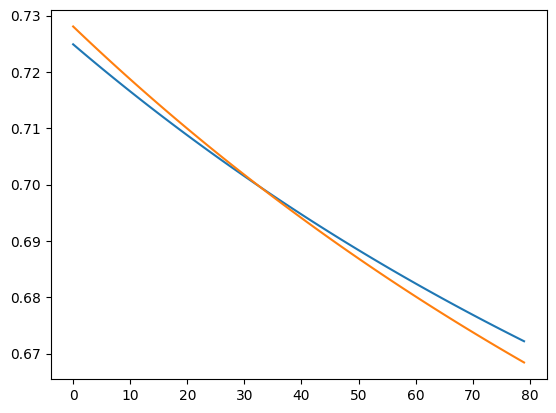

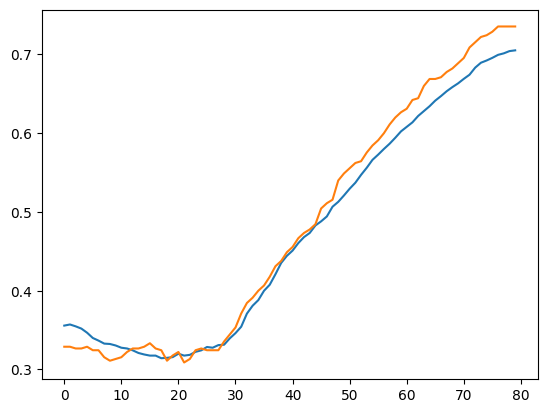

train acc: 0.7052380952380952
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.0935375621567192
last layer grad: 0.09665605988360379
relu momentum [2, 4, 1]


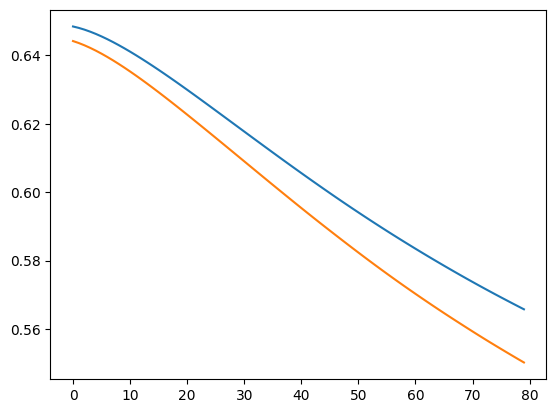

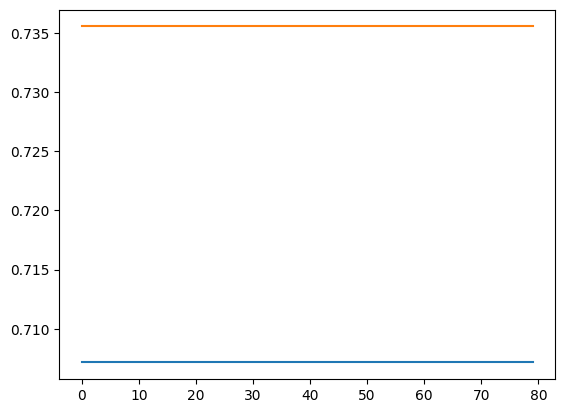

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.0721663240209317
last layer grad: 0.05240554235522209
sigmoid sgd [2, 4, 1]


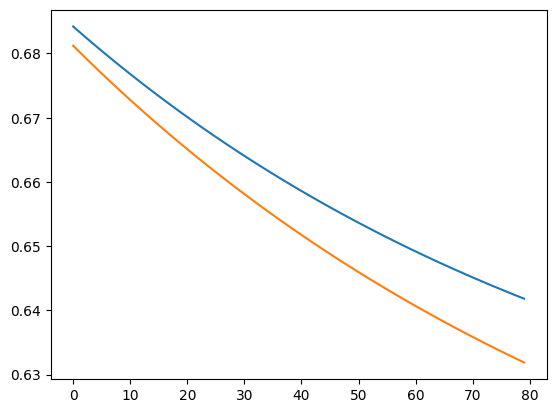

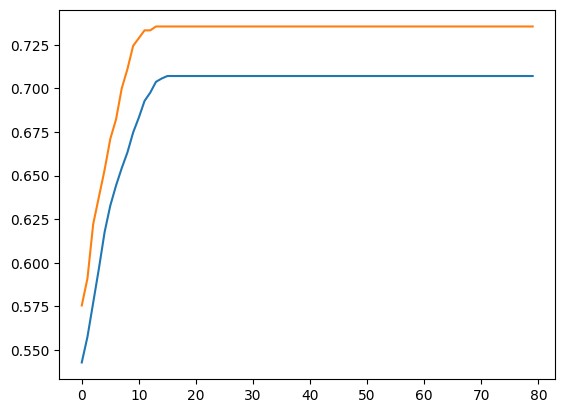

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.0013749705136942344
last layer grad: 0.13164109310782174
sigmoid momentum [2, 4, 1]


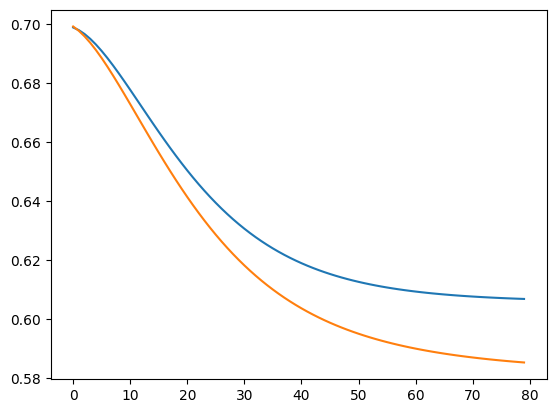

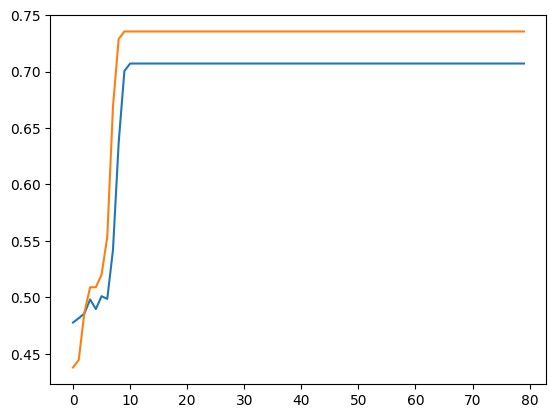

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.005921807341280677
last layer grad: 0.01988594731379445
relu sgd [2, 4, 4, 4, 4, 1]


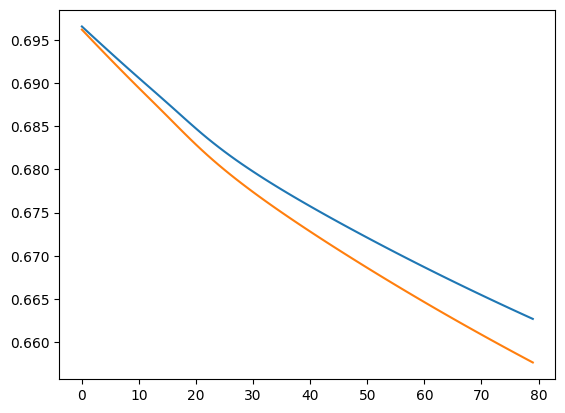

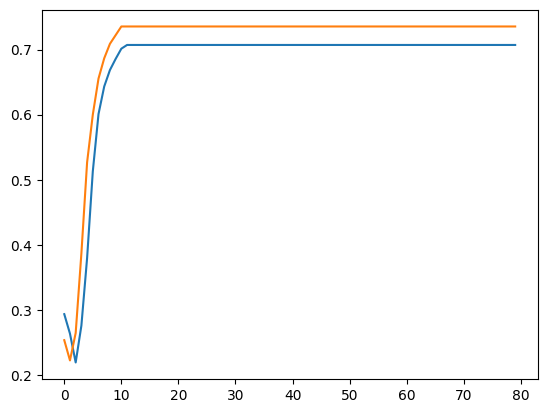

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.0033250056332898357
last layer grad: 0.008899838308389429
relu momentum [2, 4, 4, 4, 4, 1]


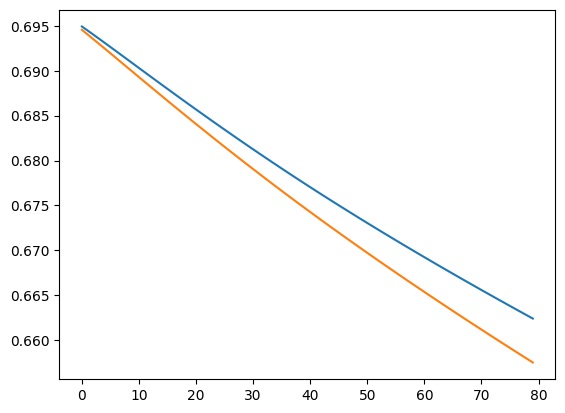

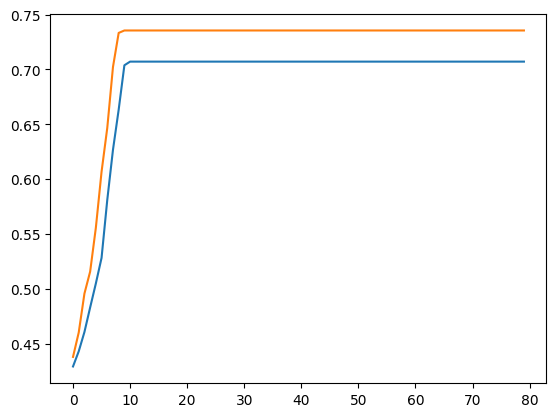

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.004404846393789885
last layer grad: 0.022652513848624087
sigmoid sgd [2, 4, 4, 4, 4, 1]


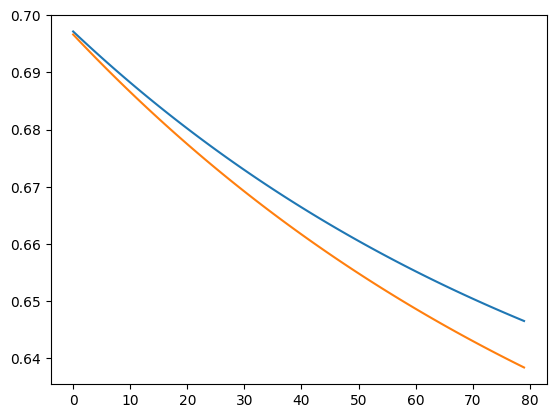

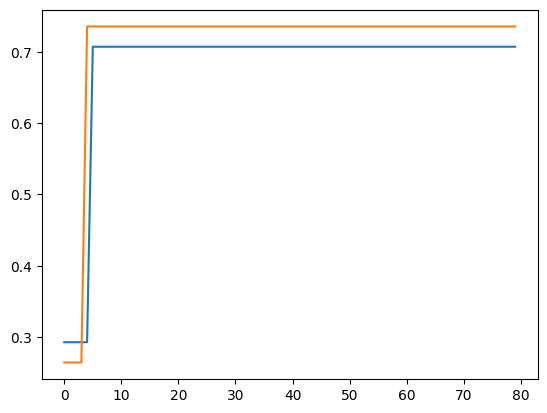

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 8.374373783931898e-06
last layer grad: 0.14355449597044068
sigmoid momentum [2, 4, 4, 4, 4, 1]


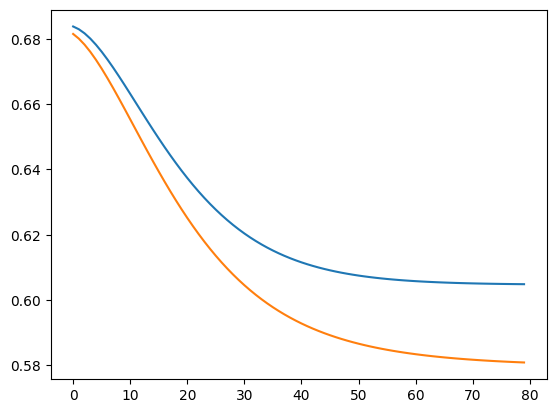

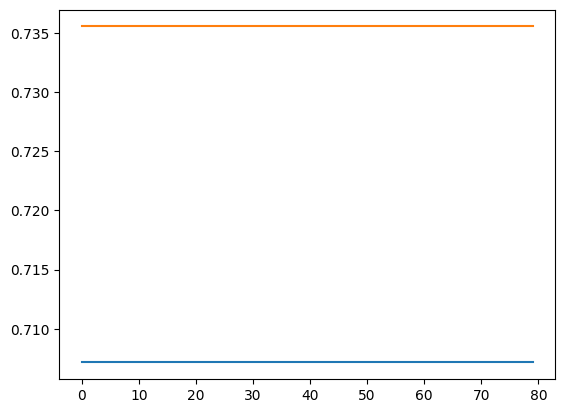

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 9.717011665798077e-06
last layer grad: 0.009281316385915738
relu sgd [2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1]


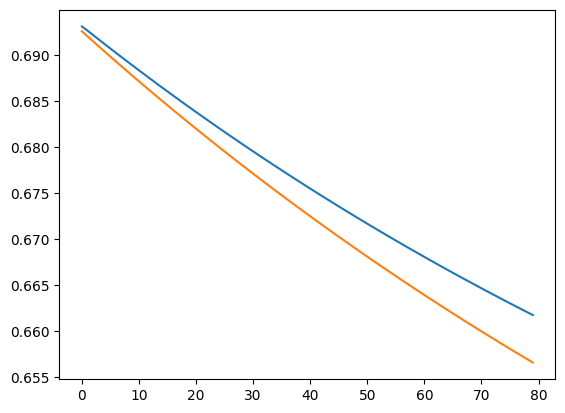

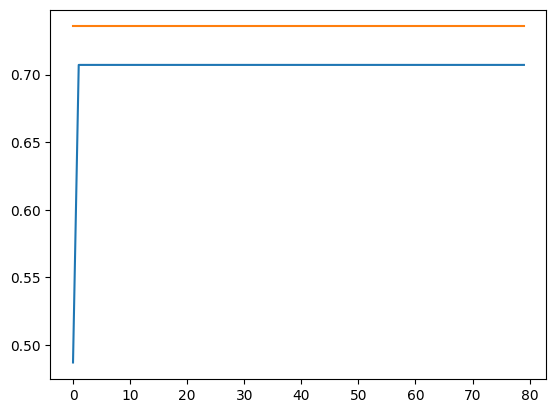

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 0.0
last layer grad: 0.009376346359307166
relu momentum [2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1]


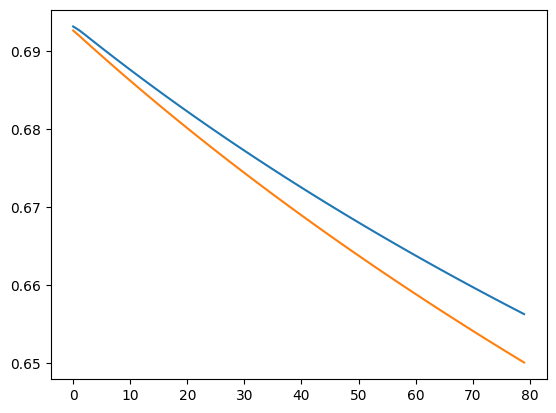

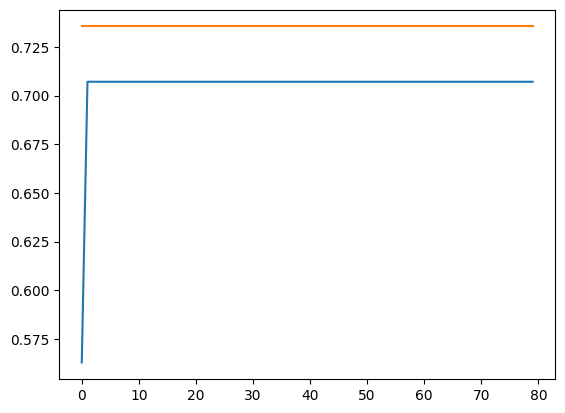

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 5.626374967392695e-06
last layer grad: 0.01478890142612326
sigmoid sgd [2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1]


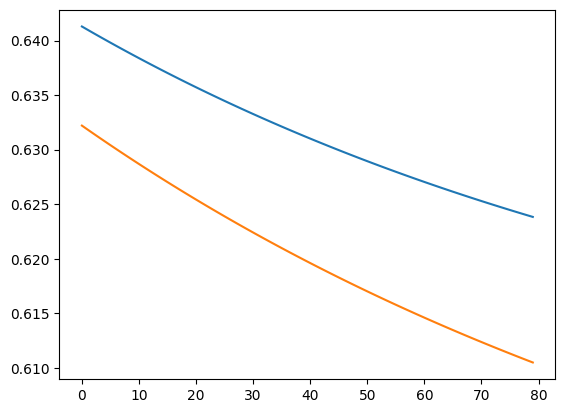

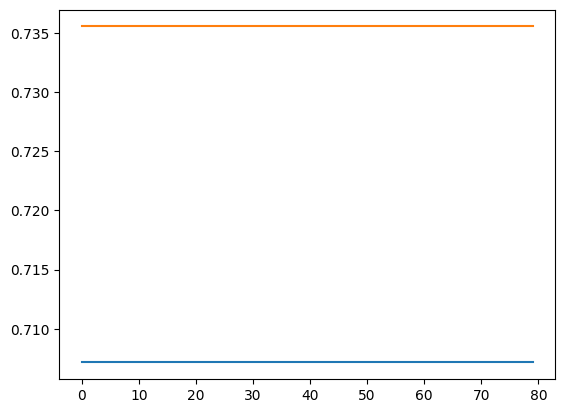

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 4.584415273696145e-11
last layer grad: 0.07963389560778154
sigmoid momentum [2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1]


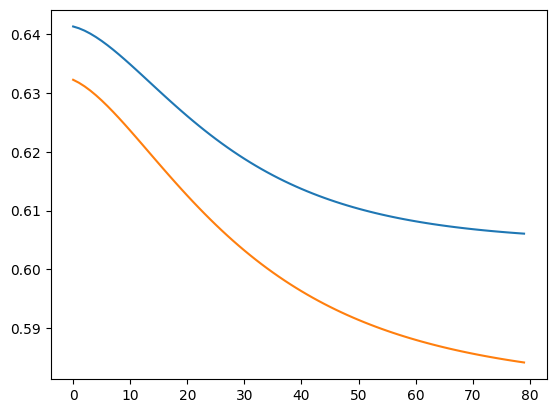

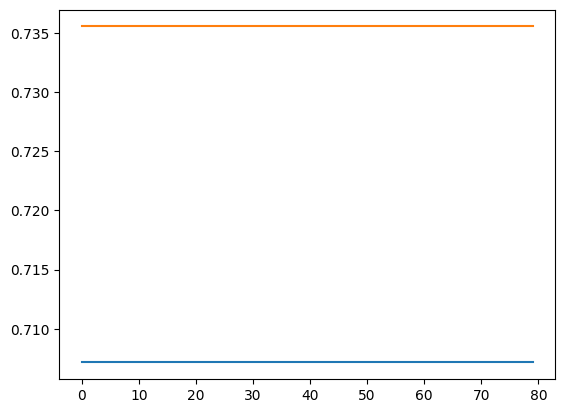

train acc: 0.7071428571428572
val acc: 0.7355555555555555
test acc: 0.7
first layer grad: 8.592133209619815e-11
last layer grad: 0.020990705212496415


In [21]:
for m in models:

    print("relu sgd",m)
    train(m,relu,relud,"sgd")

    print("relu momentum",m)
    train(m,relu,relud,"momentum")

    print("sigmoid sgd",m)
    train(m,sigmoid,sigmoidd,"sgd")

    print("sigmoid momentum",m)
    train(m,sigmoid,sigmoidd,"momentum")

In [22]:
def genimg(n):

    X=[]
    y=[]

    for i in range(n):

        img=np.zeros((8,8))

        if np.random.rand()<0.5:
            img[:,4]=1
            y.append(0)
        else:
            img[4,:]=1
            y.append(1)

        img=img+np.random.normal(0,0.1,(8,8))

        X.append(img)

    return np.array(X),np.array(y).reshape(-1,1)

In [23]:
Ximg,yimg=genimg(3000)


In [24]:
p=np.random.permutation(3000)
Ximg=Ximg[p]
yimg=yimg[p]

n1=int(0.7*3000)
n2=int(0.85*3000)

Xtr_i=Ximg[:n1]
ytr_i=yimg[:n1]

Xva_i=Ximg[n1:n2]
yva_i=yimg[n1:n2]

Xte_i=Ximg[n2:]
yte_i=yimg[n2:]

In [26]:
def conv(X,K):

    n,h,w=X.shape
    f=K.shape[0]

    o=h-f+1

    out=np.zeros((n,o,o))

    for i in range(o):
        for j in range(o):
            out[:,i,j]=np.sum(X[:,i:i+f,j:j+f]*K,axis=(1,2))

    return out

def maxpool(X):

    n,h,w=X.shape
    o=h//2

    out=np.zeros((n,o,o))

    for i in range(o):
        for j in range(o):
            out[:,i,j]=np.max(X[:,2*i:2*i+2,2*j:2*j+2],axis=(1,2))

    return out

In [28]:
def cnn_train(ep=20,lr=0.01):

    K=np.random.uniform(-0.5,0.5,(3,3))
    W=np.random.uniform(-0.5,0.5,(9,1))
    b=0

    for e in range(ep):

        Z=conv(Xtr_i,K)
        A=relu(Z)

        P=maxpool(A)

        F=P.reshape(P.shape[0],-1)

        yhat=sigmoid(F@W+b)

        loss=bce(ytr_i,yhat)

        d=yhat-ytr_i
        dW=F.T@d/len(F)
        db=np.mean(d)

        W=W-lr*dW
        b=b-lr*db

        print(e,loss)

    pt=sigmoid(maxpool(relu(conv(Xte_i,K))).reshape(Xte_i.shape[0],-1)@W+b)

    print("test acc:",acc(yte_i,pt))

In [29]:

cnn_train()

0 0.6819453789226229
1 0.6819341606650148
2 0.6819229464408462
3 0.6819117362311323
4 0.6819005300169859
5 0.6818893277796154
6 0.6818781295003261
7 0.6818669351605186
8 0.6818557447416881
9 0.6818445582254251
10 0.6818333755934138
11 0.681822196827432
12 0.6818110219093505
13 0.6817998508211329
14 0.6817886835448353
15 0.681777520062605
16 0.6817663603566806
17 0.6817552044093917
18 0.6817440522031579
19 0.6817329037204891
test acc: 0.6222222222222222
